# Experiment B — Adaptive System Identification

Comparison of **Frank–Wolfe**, **certainty equivalence**, **naive exploration**,
and a **frequency-based periodic-input baseline**.

## Dynamics, information matrices, and data tools

| Function | Purpose |
|---|---|
| `_seed_from_key` | Converts supported random-key formats into a stable seed. |
| `generalized_finite_horizon_lqr_with_noise` | Solves a noisy generalized finite-horizon LQR problem. |
| `compute_cost_covariance_sum_time_invariant` | Computes moments for feedback with optional probing noise. |
| `compute_cost_covariance_for_open_loop_inputs` | Computes moments for deterministic open-loop inputs. |
| `frequency_based_periodic_input_design` | Searches a tuned frequency/direction grid under the covariance budget. |
| `generate_noise_keys` | Creates repeatable process-noise streams. |
| `generate_prior_data` | Generates $\Sigma^{(0)}$ and $\bar\Sigma^{(0)}$. |
| `solve_budget_constrained_lqr` | Runs the shared robust folded bisection for FW and CE. |

In [46]:
import os
import numpy as np
import matplotlib.pyplot as plt
import scipy.linalg as la
from scipy.linalg import solve_discrete_are, solve_discrete_lyapunov
from numpy import linalg as LA
from scipy import signal


def _seed_from_key(key):
    """Convert an int, NumPy Generator, or old array-like PRNG key to a stable seed."""
    if isinstance(key, np.random.Generator):
        return key
    if key is None:
        return 0
    arr = np.asarray(key)
    if arr.shape == ():
        return int(arr) % (2**32 - 1)
    return int(np.sum(arr.astype(np.uint64)) % (2**32 - 1))


def generalized_finite_horizon_lqr_with_noise(
    A, B, Q, R, N, Sigma_w, T=100, x0=None, Qf=None
):
    """
    Solve a finite-horizon generalized LQR problem using a backward Riccati recursion.

    Dynamics:
        x_{t+1} = A x_t + B u_t + w_t

    Stage cost:
        x_t^T Q x_t + u_t^T R u_t + 2 x_t^T N u_t

    Controller convention:
        u_t = -K_t x_t

    Returns:
        K_list   : feedback gains, shape (T, du, dx)
        P_list   : Riccati matrices, shape (T+1, dx, dx)
        c_list   : additive noise-cost terms
        J_star   : optional cost-to-go from x0
        feasible : True if all control Hessians are positive definite
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    Q = np.asarray(Q, dtype=float)
    R = np.asarray(R, dtype=float)
    N = np.asarray(N, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)

    dx, du = B.shape
    Qf = np.zeros((dx, dx)) if Qf is None else np.asarray(Qf, dtype=float)

    P_next = Qf.copy()
    feasible = True
    K_rev, P_rev, c_rev = [], [], []

    for _ in range(int(T)):
        BtP = B.T @ P_next
        AtP = A.T @ P_next

        # Control Hessian in the Riccati recursion.
        M_mat = R + BtP @ B
        rhs = N + AtP @ B

        eig_min = np.min(np.linalg.eigvalsh(0.5 * (M_mat + M_mat.T)))
        feasible = feasible and (eig_min > 1e-8)

        if feasible:
            K = np.linalg.solve(M_mat, rhs.T)
        else:
            # Keep dimensions valid if this lambda value is not admissible.
            K = np.zeros((du, dx))

        P = Q + A.T @ P_next @ A - rhs @ K
        P = 0.5 * (P + P.T)
        c = np.trace(P_next @ Sigma_w)

        K_rev.append(K)
        P_rev.append(P)
        c_rev.append(c)
        P_next = P

    K_list = np.stack(K_rev[::-1], axis=0)
    P_list = np.concatenate([np.stack(P_rev[::-1], axis=0), Qf[None, :, :]], axis=0)
    c_list = np.concatenate([np.array(c_rev[::-1], dtype=float), np.zeros(1)])

    J_star = None
    if x0 is not None:
        x0 = np.asarray(x0, dtype=float)
        J_star = float(x0 @ P_list[0] @ x0 + c_list[0])

    return K_list, P_list, c_list, J_star, feasible


generalized_finite_horizon_lqr_with_noise_jax = generalized_finite_horizon_lqr_with_noise


def compute_cost_covariance_sum_time_invariant(
    A, B, K_list, Sigma_w, T, W, Sigma_x0=None, sigma_probe=0
):
    """
    Compute the predicted finite-horizon state-input covariance under a gain sequence.

    The returned covariance is
        sum_{t=0}^{T-1} E[[x_t; u_t][x_t; u_t]^T].

    If sigma_probe > 0, independent Gaussian probing input is added to u_t.
    This is used by the naive-exploration baseline.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    K_array = np.asarray(K_list, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    dx, du = B.shape
    Sigma_x = np.zeros((dx, dx)) if Sigma_x0 is None else np.asarray(Sigma_x0, dtype=float).copy()

    Sigma_pi = np.zeros((dx + du, dx + du))

    for K in K_array[:int(T)]:
        A_cl = A - B @ K
        Sigma_u = K @ Sigma_x @ K.T + sigma_probe**2 * np.eye(du)
        Sigma_xu = -Sigma_x @ K.T

        Sigma_z = np.block([
            [Sigma_x,    Sigma_xu],
            [Sigma_xu.T, Sigma_u],
        ])
        Sigma_pi = Sigma_pi + Sigma_z

        Sigma_x_next = A_cl @ Sigma_x @ A_cl.T + Sigma_w + sigma_probe**2 * B @ B.T
        Sigma_x = 0.5 * (Sigma_x_next + Sigma_x_next.T)

    total_cost = float(np.trace(W @ Sigma_pi))
    return total_cost, Sigma_pi


compute_cost_covariance_sum_time_invariant_jax = compute_cost_covariance_sum_time_invariant


def compute_cost_covariance_for_open_loop_inputs(
    A, B, U_seq, Sigma_w, W, Sigma_x0=None, x_mean0=None
):
    """
    Compute the finite-horizon second-moment matrix for a deterministic input sequence.

    This is used by the frequency-based baseline. The policy is open-loop and
    periodic, so the input has a nonzero deterministic mean. Since the design
    objective uses E[z_t z_t^T], we include both state covariance and state mean.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    U_seq = np.asarray(U_seq, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    T = U_seq.shape[0]
    dx, du = B.shape
    Sigma_x = np.zeros((dx, dx)) if Sigma_x0 is None else np.asarray(Sigma_x0, dtype=float).copy()
    mu_x = np.zeros(dx) if x_mean0 is None else np.asarray(x_mean0, dtype=float).copy()

    Sigma_pi = np.zeros((dx + du, dx + du))

    for t in range(T):
        u = U_seq[t]

        Exx = Sigma_x + np.outer(mu_x, mu_x)
        Exu = np.outer(mu_x, u)
        Euu = np.outer(u, u)

        Sigma_z = np.block([
            [Exx,   Exu],
            [Exu.T, Euu],
        ])
        Sigma_pi = Sigma_pi + Sigma_z

        mu_x = A @ mu_x + B @ u
        Sigma_x_next = A @ Sigma_x @ A.T + Sigma_w
        Sigma_x = 0.5 * (Sigma_x_next + Sigma_x_next.T)

    total_cost = float(np.trace(W @ Sigma_pi))
    return total_cost, Sigma_pi


def frequency_based_periodic_input_design(
    A_hat, B_hat, Sigma_k_anchor, Sigma_w, T, W, H, gamma, rng=None
):
    """
    Design an open-loop periodic probing sequence based on a frequency-domain search.

    The paper's method repeatedly designs periodic inputs that excite directions
    suggested by the current model estimate. This lightweight baseline keeps that
    spirit: it searches over sinusoidal input frequencies and input directions,
    scales each candidate to satisfy the same covariance budget, and chooses the
    candidate that gives the best predicted information objective.

    Existing FW, CE, and naive baselines are untouched; this is only an extra
    comparison baseline.
    """
    A_hat = np.asarray(A_hat, dtype=float)
    B_hat = np.asarray(B_hat, dtype=float)
    Sigma_k_anchor = np.asarray(Sigma_k_anchor, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    dx, du = B_hat.shape
    # Use the same identity objective weighting as the Frank-Wolfe experiment.
    # H is used only to score frequency-based candidates via
    # Tr(H (Sigma_k + Sigma_candidate)^{-1}). We fix it to identity for this baseline.
    H = np.eye(dx + du)
    rng = np.random.default_rng(0) if rng is None else rng

    # Candidate periodic frequencies. Avoid the zero-frequency input and use a
    # modest grid up to the Nyquist-like limit for the finite horizon.
    num_freqs = max(1, T // 2)
    base_frequencies = 2.0 * np.pi * np.arange(1, num_freqs + 1) / max(T, 1)
    dense_frequencies = np.linspace(base_frequencies[0], np.pi, 4 * num_freqs)
    frequencies = np.unique(np.concatenate([base_frequencies, dense_frequencies]))

    # Candidate input directions. For multi-input systems, use coordinate axes
    # and a few random unit directions. For scalar inputs, this is just [1].
    directions = [np.eye(du)[i] for i in range(du)]
    if du > 1:
        for _ in range(min(16, 8 * du)):  # TUNE B1: denser direction search
            v = rng.normal(size=du)
            nrm = np.linalg.norm(v)
            if nrm > 1e-12:
                directions.append(v / nrm)

    best_obj = np.inf
    best_U = np.zeros((T, du))
    best_Sigma_pi = np.zeros((dx + du, dx + du))
    best_budget = 0.0
    best_info = {'frequency': None, 'direction': None, 'amplitude': 0.0}

    t_grid = np.arange(T)

    for omega in frequencies:
        for direction in directions:
            # Unit-amplitude periodic input. Cosine is enough for this baseline;
            # the phase is kept fixed for reproducibility.
            U_unit = np.cos(omega * t_grid)[:, None] * direction[None, :]

            # Scale this periodic input by bisection so it satisfies the same
            # covariance budget used by the other methods.
            amp_low, amp_high = 0.0, 1.0
            for _ in range(60):
                budget_high, _ = compute_cost_covariance_for_open_loop_inputs(
                    A_hat, B_hat, amp_high * U_unit, Sigma_w, W
                )
                if budget_high >= gamma:
                    break
                amp_high *= 2.0

            for _ in range(80):
                amp_mid = 0.5 * (amp_low + amp_high)
                budget_mid, Sigma_pi_mid = compute_cost_covariance_for_open_loop_inputs(
                    A_hat, B_hat, amp_mid * U_unit, Sigma_w, W
                )
                if budget_mid > gamma:
                    amp_high = amp_mid
                else:
                    amp_low = amp_mid

            amp = amp_low
            budget, Sigma_pi = compute_cost_covariance_for_open_loop_inputs(
                A_hat, B_hat, amp * U_unit, Sigma_w, W
            )

            # Choose the periodic input that most improves the predicted design
            # Objective Tr(H (Sigma^{(k)} + Sigma^pi)^{-1}), using H = I.
            try:
                obj = float(np.trace(H @ np.linalg.inv(Sigma_k_anchor + Sigma_pi)))
            except np.linalg.LinAlgError:
                obj = np.inf

            if obj < best_obj:
                best_obj = obj
                best_U = amp * U_unit
                best_Sigma_pi = Sigma_pi
                best_budget = budget
                best_info = {
                    'frequency': float(omega),
                    'direction': np.asarray(direction, dtype=float).copy(),
                    'amplitude': float(amp),
                }

    return best_U, best_Sigma_pi, best_budget, best_info


def generate_noise_keys(key, num_episodes, T, du, dx):
    """
    Generate all random probe and process-noise samples used in the experiment.

    The name is kept for compatibility with the old JAX version, but this function
    now returns sampled arrays directly, not PRNG keys.
    """
    rng = key if isinstance(key, np.random.Generator) else np.random.default_rng(_seed_from_key(key))
    return {
        'probe': rng.normal(size=(num_episodes, T, du)),
        'noise': rng.multivariate_normal(np.zeros(dx), np.eye(dx), size=(num_episodes, T)),
    }


def generate_prior_data(A, B, stabilize_gain, Sigma_w, T_prior, key):
    """
    Generate the initial information and transition cross-information matrices.

    The prior trajectory uses a stabilizing controller plus tiny probing noise.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    stabilize_gain = np.asarray(stabilize_gain, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)

    dx, du = B.shape
    rng = key if isinstance(key, np.random.Generator) else np.random.default_rng(_seed_from_key(key))
    x = rng.normal(size=dx)
    X_hist, U_hist, Y_hist = [], [], []

    for _ in range(T_prior):
        probe = 0.0001 * rng.normal(size=du)
        u = -stabilize_gain @ x + probe

        noise = rng.multivariate_normal(np.zeros(dx), Sigma_w)
        y = A @ x + B @ u + noise

        X_hist.append(x)
        U_hist.append(u)
        Y_hist.append(y)
        x = y

    X_mat = np.stack(X_hist, axis=1)
    U_mat = np.stack(U_hist, axis=1)
    Y_mat = np.stack(Y_hist, axis=1)

    Z = np.concatenate([X_mat, U_mat], axis=0)
    Sigma_0 = Z @ Z.T
    bar_Sigma_0 = Y_mat @ Z.T
    return Sigma_0, bar_Sigma_0


def solve_budget_constrained_lqr(
    A, B, M_base, W, Sigma_w, T, beta, tol=1e-8, max_iter=100
):
    """Robust folded dual bisection shared by FW and CE.

    Returns ``(K, covariance, budget, lambda, used_fallback)``. The numerical
    LQR and covariance routines are unchanged; only their dual search is
    centralized here.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    M_base = np.asarray(M_base, dtype=float)
    W = np.asarray(W, dtype=float)
    dx = A.shape[0]

    def evaluate(stage_matrix):
        Q = stage_matrix[:dx, :dx]
        R = stage_matrix[dx:, dx:]
        N = stage_matrix[:dx, dx:]
        K, _, _, _, feasible = generalized_finite_horizon_lqr_with_noise(
            A, B, Q, R, N, Sigma_w, T
        )
        if not feasible:
            return None
        budget, covariance = compute_cost_covariance_sum_time_invariant(
            A, B, K, Sigma_w, T, W
        )
        return K, covariance, float(budget)

    # minimum-energy policy/value b0 is always the stored fallback.
    energy = evaluate(W)
    if energy is None:
        raise RuntimeError("Minimum-energy comparison policy is not well posed.")
    K_energy, covariance_energy, b0 = energy
    if beta <= b0:
        return K_energy, covariance_energy, b0, np.inf, True

    zero = evaluate(M_base)
    if zero is not None and zero[2] <= beta:
        return zero[0], zero[1], zero[2], 0.0, False

    # Lemma-3(iv)-style bracket with expansion as numerical safety.
    mu_W = float(np.min(np.linalg.eigvalsh(0.5 * (W + W.T))))
    if mu_W <= 0.0:
        raise ValueError("W must be positive definite for the dual bracket.")
    max_M_norm = float(np.linalg.norm(0.5 * (M_base + M_base.T), ord=2))
    lam_hi = (beta + b0) / (beta - b0) * max_M_norm / mu_W
    lam_hi = max(lam_hi, 1e-8)

    best = (K_energy, covariance_energy, b0)
    found = False
    for _ in range(80):
        trial = evaluate(M_base + lam_hi * W)
        if trial is not None and trial[2] <= beta:
            best, found = trial, True
            break
        lam_hi *= 2.0
    if not found:
        return K_energy, covariance_energy, b0, np.inf, True

    # one folded bisection handles both admissibility and the budget.
    lam_lo = 0.0
    for _ in range(max_iter):
        if lam_hi - lam_lo <= max(1e-12, tol * lam_hi):
            break
        lam_mid = 0.5 * (lam_lo + lam_hi)
        trial = evaluate(M_base + lam_mid * W)
        if trial is None or trial[2] > beta:
            lam_lo = lam_mid
        else:
            lam_hi = lam_mid
            best = trial
            if best[2] >= beta * (1.0 - 1e-8):
                break

    return best[0], best[1], best[2], lam_hi, False




## Optional Numba acceleration

The preceding functions are complete NumPy/SciPy implementations. This cell only
installs specialized fast paths when Numba is available; otherwise it preserves
the reference implementations.

| Accelerated routine | Purpose |
|---|---|
| `_covariance_feedback_n2m1_numba` | Accelerates feedback covariance propagation. |
| `_evaluate_stage_n2m1_numba` | Accelerates the combined Riccati and budget evaluation. |
| `_covariance_open_loop_n2m1_numba` | Accelerates periodic open-loop moment propagation. |
| `compute_cost_covariance_sum_time_invariant` | Uses the fast feedback kernel when supported and otherwise calls the reference function. |
| `compute_cost_covariance_for_open_loop_inputs` | Uses the fast open-loop kernel when supported and otherwise calls the reference function. |
| `solve_budget_constrained_lqr` | Uses the fast Riccati/budget kernel when supported and otherwise calls the reference function. |


In [47]:
# ============================================================================
# Optional Numba acceleration
# ============================================================================
# The NumPy/SciPy implementations above are the reference implementations.
# If Numba is installed, this cell installs specialized fast paths for the
# experiment's 2-state/1-input system. Otherwise, the reference code is used.

try:
    import numba as nb
    _NUMBA_AVAILABLE = True
except Exception:
    nb = None
    _NUMBA_AVAILABLE = False

_compute_feedback_numpy_reference = compute_cost_covariance_sum_time_invariant
_compute_open_loop_numpy_reference = compute_cost_covariance_for_open_loop_inputs
_solve_budget_numpy_reference = solve_budget_constrained_lqr

if _NUMBA_AVAILABLE:
    @nb.njit
    def _covariance_feedback_n2m1_numba(
        A, B, K, Sigma_w, horizon, W, Sigma_x0, sigma_probe
    ):
        Sx = Sigma_x0.copy()
        total = np.zeros((3, 3), dtype=np.float64)
        probe_var = sigma_probe * sigma_probe
        for t in range(horizon):
            k0 = K[t, 0, 0]; k1 = K[t, 0, 1]
            xu0 = -(Sx[0, 0] * k0 + Sx[0, 1] * k1)
            xu1 = -(Sx[1, 0] * k0 + Sx[1, 1] * k1)
            uu = (k0 * (Sx[0, 0] * k0 + Sx[0, 1] * k1)
                  + k1 * (Sx[1, 0] * k0 + Sx[1, 1] * k1) + probe_var)
            total[0, 0] += Sx[0, 0]; total[0, 1] += Sx[0, 1]
            total[1, 0] += Sx[1, 0]; total[1, 1] += Sx[1, 1]
            total[0, 2] += xu0; total[2, 0] += xu0
            total[1, 2] += xu1; total[2, 1] += xu1
            total[2, 2] += uu
            f00 = A[0, 0] - B[0, 0] * k0; f01 = A[0, 1] - B[0, 0] * k1
            f10 = A[1, 0] - B[1, 0] * k0; f11 = A[1, 1] - B[1, 0] * k1
            n00 = f00 * (Sx[0, 0] * f00 + Sx[0, 1] * f01) + f01 * (
                Sx[1, 0] * f00 + Sx[1, 1] * f01
            ) + Sigma_w[0, 0] + probe_var * B[0, 0] * B[0, 0]
            n01 = f00 * (Sx[0, 0] * f10 + Sx[0, 1] * f11) + f01 * (
                Sx[1, 0] * f10 + Sx[1, 1] * f11
            ) + Sigma_w[0, 1] + probe_var * B[0, 0] * B[1, 0]
            n11 = f10 * (Sx[0, 0] * f10 + Sx[0, 1] * f11) + f11 * (
                Sx[1, 0] * f10 + Sx[1, 1] * f11
            ) + Sigma_w[1, 1] + probe_var * B[1, 0] * B[1, 0]
            Sx[0, 0] = n00; Sx[0, 1] = n01; Sx[1, 0] = n01; Sx[1, 1] = n11
        budget = 0.0
        for i in range(3):
            for j in range(3):
                budget += W[i, j] * total[j, i]
        return budget, total

    @nb.njit
    def _evaluate_stage_n2m1_numba(A, B, M, Sigma_w, horizon, W):
        Ms = 0.5 * (M + M.T)
        K = np.zeros((horizon, 1, 2), dtype=np.float64)
        P = np.zeros((2, 2), dtype=np.float64)
        for t in range(horizon - 1, -1, -1):
            b0 = B[0, 0]; b1 = B[1, 0]
            pb0 = P[0, 0] * b0 + P[0, 1] * b1
            pb1 = P[1, 0] * b0 + P[1, 1] * b1
            s = Ms[2, 2] + b0 * pb0 + b1 * pb1
            if s <= 1e-8:
                return False, K, np.zeros((3, 3)), np.inf
            r0 = (Ms[2, 0] + b0 * (P[0, 0] * A[0, 0] + P[0, 1] * A[1, 0])
                  + b1 * (P[1, 0] * A[0, 0] + P[1, 1] * A[1, 0]))
            r1 = (Ms[2, 1] + b0 * (P[0, 0] * A[0, 1] + P[0, 1] * A[1, 1])
                  + b1 * (P[1, 0] * A[0, 1] + P[1, 1] * A[1, 1]))
            K[t, 0, 0] = r0 / s; K[t, 0, 1] = r1 / s
            AtPA = A.T @ P @ A
            P[0, 0] = Ms[0, 0] + AtPA[0, 0] - r0 * r0 / s
            P[0, 1] = Ms[0, 1] + AtPA[0, 1] - r0 * r1 / s
            P[1, 0] = P[0, 1]
            P[1, 1] = Ms[1, 1] + AtPA[1, 1] - r1 * r1 / s
        budget, covariance = _covariance_feedback_n2m1_numba(
            A, B, K, Sigma_w, horizon, W, np.zeros((2, 2)), 0.0
        )
        return True, K, covariance, budget


if _NUMBA_AVAILABLE:
    @nb.njit
    def _covariance_open_loop_n2m1_numba(A, B, U, Sigma_w, W, Sigma_x0, mean0):
        Sx = Sigma_x0.copy()
        mean = mean0.copy()
        total = np.zeros((3, 3), dtype=np.float64)
        for t in range(U.shape[0]):
            u = U[t, 0]
            exx00 = Sx[0, 0] + mean[0] * mean[0]
            exx01 = Sx[0, 1] + mean[0] * mean[1]
            exx11 = Sx[1, 1] + mean[1] * mean[1]
            total[0, 0] += exx00; total[0, 1] += exx01
            total[1, 0] += exx01; total[1, 1] += exx11
            total[0, 2] += mean[0] * u; total[2, 0] += mean[0] * u
            total[1, 2] += mean[1] * u; total[2, 1] += mean[1] * u
            total[2, 2] += u * u

            m0 = A[0, 0] * mean[0] + A[0, 1] * mean[1] + B[0, 0] * u
            m1 = A[1, 0] * mean[0] + A[1, 1] * mean[1] + B[1, 0] * u
            n00 = A[0, 0] * (Sx[0, 0] * A[0, 0] + Sx[0, 1] * A[0, 1]) + A[0, 1] * (
                Sx[1, 0] * A[0, 0] + Sx[1, 1] * A[0, 1]
            ) + Sigma_w[0, 0]
            n01 = A[0, 0] * (Sx[0, 0] * A[1, 0] + Sx[0, 1] * A[1, 1]) + A[0, 1] * (
                Sx[1, 0] * A[1, 0] + Sx[1, 1] * A[1, 1]
            ) + Sigma_w[0, 1]
            n11 = A[1, 0] * (Sx[0, 0] * A[1, 0] + Sx[0, 1] * A[1, 1]) + A[1, 1] * (
                Sx[1, 0] * A[1, 0] + Sx[1, 1] * A[1, 1]
            ) + Sigma_w[1, 1]
            mean[0] = m0; mean[1] = m1
            Sx[0, 0] = n00; Sx[0, 1] = n01; Sx[1, 0] = n01; Sx[1, 1] = n11

        budget = 0.0
        for i in range(3):
            for j in range(3):
                budget += W[i, j] * total[j, i]
        return budget, total


def compute_cost_covariance_sum_time_invariant(
    A, B, K_list, Sigma_w, T, W, Sigma_x0=None, sigma_probe=0
):
    """
    Compute the predicted finite-horizon state-input covariance under a gain sequence.

    The returned covariance is
        sum_{t=0}^{T-1} E[[x_t; u_t][x_t; u_t]^T].

    If sigma_probe > 0, independent Gaussian probing input is added to u_t.
    This is used by the naive-exploration baseline.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    K_array = np.asarray(K_list, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    dx, du = B.shape
    Sigma_x = np.zeros((dx, dx)) if Sigma_x0 is None else np.asarray(Sigma_x0, dtype=float).copy()
    # Numba covariance propagation for the experiment's 2x1 system.
    if _NUMBA_AVAILABLE and A.shape == (2, 2) and B.shape == (2, 1):
        Sigma_x0_fast = (np.zeros((2, 2)) if Sigma_x0 is None
                       else np.asarray(Sigma_x0, dtype=float))
        return _covariance_feedback_n2m1_numba(
            np.ascontiguousarray(A), np.ascontiguousarray(B),
            np.ascontiguousarray(K_array), np.ascontiguousarray(Sigma_w),
            int(T), np.ascontiguousarray(W), np.ascontiguousarray(Sigma_x0_fast),
            float(sigma_probe),
        )

    return _compute_feedback_numpy_reference(
        A, B, K_list, Sigma_w, T, W, Sigma_x0=Sigma_x0,
        sigma_probe=sigma_probe,
    )


def compute_cost_covariance_for_open_loop_inputs(
    A, B, U_seq, Sigma_w, W, Sigma_x0=None, x_mean0=None
):
    """
    Compute the finite-horizon second-moment matrix for a deterministic input sequence.

    This is used by the frequency-based baseline. The policy is open-loop and
    periodic, so the input has a nonzero deterministic mean. Since the design
    objective uses E[z_t z_t^T], we include both state covariance and state mean.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    U_seq = np.asarray(U_seq, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)
    W = np.asarray(W, dtype=float)

    T = U_seq.shape[0]
    dx, du = B.shape
    Sigma_x = np.zeros((dx, dx)) if Sigma_x0 is None else np.asarray(Sigma_x0, dtype=float).copy()
    mu_x = np.zeros(dx) if x_mean0 is None else np.asarray(x_mean0, dtype=float).copy()
    # accelerate the existing scalar-input open-loop moment recursion.
    if _NUMBA_AVAILABLE and A.shape == (2, 2) and B.shape == (2, 1):
        Sigma_x0_fast = (np.zeros((2, 2)) if Sigma_x0 is None
                       else np.asarray(Sigma_x0, dtype=float))
        mean0_fast = (np.zeros(2) if x_mean0 is None
                      else np.asarray(x_mean0, dtype=float))
        return _covariance_open_loop_n2m1_numba(
            np.ascontiguousarray(A), np.ascontiguousarray(B),
            np.ascontiguousarray(U_seq), np.ascontiguousarray(Sigma_w),
            np.ascontiguousarray(W), np.ascontiguousarray(Sigma_x0_fast),
            np.ascontiguousarray(mean0_fast),
        )

    return _compute_open_loop_numpy_reference(
        A, B, U_seq, Sigma_w, W, Sigma_x0=Sigma_x0, x_mean0=x_mean0
    )


def solve_budget_constrained_lqr(
    A, B, M_base, W, Sigma_w, T, beta, tol=1e-8, max_iter=100
):
    """Robust folded dual bisection shared by FW and CE.

    Returns ``(K, covariance, budget, lambda, used_fallback)``. The numerical
    LQR and covariance routines are unchanged; only their dual search is
    centralized here.
    """
    A = np.asarray(A, dtype=float)
    B = np.asarray(B, dtype=float)
    if not (_NUMBA_AVAILABLE and A.shape == (2, 2) and B.shape == (2, 1)):
        return _solve_budget_numpy_reference(
            A, B, M_base, W, Sigma_w, T, beta, tol=tol, max_iter=max_iter
        )

    M_base = np.asarray(M_base, dtype=float)
    W = np.asarray(W, dtype=float)
    dx = A.shape[0]

    def evaluate(stage_matrix):
        # FAST B1: combined Numba Riccati/covariance evaluation when dimensions match.
        if _NUMBA_AVAILABLE and A.shape == (2, 2) and B.shape == (2, 1):
            feasible, K, covariance, budget = _evaluate_stage_n2m1_numba(
                np.ascontiguousarray(A), np.ascontiguousarray(B),
                np.ascontiguousarray(stage_matrix), np.ascontiguousarray(Sigma_w),
                int(T), np.ascontiguousarray(W),
            )
            return None if not feasible else (K, covariance, float(budget))
        Q = stage_matrix[:dx, :dx]
        R = stage_matrix[dx:, dx:]
        N = stage_matrix[:dx, dx:]
        K, _, _, _, feasible = generalized_finite_horizon_lqr_with_noise(
            A, B, Q, R, N, Sigma_w, T
        )
        if not feasible:
            return None
        budget, covariance = compute_cost_covariance_sum_time_invariant(
            A, B, K, Sigma_w, T, W
        )
        return K, covariance, float(budget)

    # minimum-energy policy/value b0 is always the stored fallback.
    energy = evaluate(W)
    if energy is None:
        raise RuntimeError("Minimum-energy comparison policy is not well posed.")
    K_energy, covariance_energy, b0 = energy
    if beta <= b0:
        return K_energy, covariance_energy, b0, np.inf, True

    zero = evaluate(M_base)
    if zero is not None and zero[2] <= beta:
        return zero[0], zero[1], zero[2], 0.0, False

    # Lemma-3(iv)-style bracket with expansion as numerical safety.
    mu_W = float(np.min(np.linalg.eigvalsh(0.5 * (W + W.T))))
    if mu_W <= 0.0:
        raise ValueError("W must be positive definite for the dual bracket.")
    max_M_norm = float(np.linalg.norm(0.5 * (M_base + M_base.T), ord=2))
    lam_hi = (beta + b0) / (beta - b0) * max_M_norm / mu_W
    lam_hi = max(lam_hi, 1e-8)

    best = (K_energy, covariance_energy, b0)
    found = False
    for _ in range(80):
        trial = evaluate(M_base + lam_hi * W)
        if trial is not None and trial[2] <= beta:
            best, found = trial, True
            break
        lam_hi *= 2.0
    if not found:
        return K_energy, covariance_energy, b0, np.inf, True

    # one folded bisection handles both admissibility and the budget.
    lam_lo = 0.0
    for _ in range(max_iter):
        if lam_hi - lam_lo <= max(1e-12, tol * lam_hi):
            break
        lam_mid = 0.5 * (lam_lo + lam_hi)
        trial = evaluate(M_base + lam_mid * W)
        if trial is None or trial[2] > beta:
            lam_lo = lam_mid
        else:
            lam_hi = lam_mid
            best = trial
            if best[2] >= beta * (1.0 - 1e-8):
                break

    return best[0], best[1], best[2], lam_hi, False


print(
    "Numba fast paths installed." if _NUMBA_AVAILABLE
    else "Numba unavailable; using the NumPy/SciPy reference implementations."
)


Numba fast paths installed.


## Plotting and summaries

| Function | Purpose |
|---|---|
| `plot_single_seed_results` | Plots estimation error for one seed. |
| `plot_objective_cost_results` | Plots design-objective progression. |
| `summarize_monte_carlo` | Computes Monte Carlo summary statistics. |
| `_save_current_figure_tikz` | Exports the current figure when TikZ support is available. |
| `plot_monte_carlo_bands` | Plots median curves and percentile bands. |

In [48]:
def plot_single_seed_results(episodes, errors_our, errors_ce, errors_naive, errors_frequency_based=None):
    """Plot estimation-error curves on a log scale."""
    plt.figure(figsize=(7, 4))
    plt.semilogy(episodes, errors_our, marker='o', label='Frank-Wolfe')
    plt.semilogy(episodes, errors_ce, marker='o', label='Certainty equivalence')
    plt.semilogy(episodes, errors_naive, marker='o', label='Naive exploration')
    if errors_frequency_based is not None:
        plt.semilogy(episodes, errors_frequency_based, marker='o', label='Frequency-based')
    plt.xlabel('Episode')
    plt.ylabel(r'$\|[\hat A\ \hat B]-[A\ B]\|_F$')
    plt.title('Estimation error for $(A,B)$, log scale')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()


def plot_objective_cost_results(episodes, costs_our, costs_ce, costs_naive, costs_frequency_based=None):
    """Plot design-objective curves on a log scale."""
    plt.figure(figsize=(7, 4))
    plt.semilogy(episodes, costs_our, marker='o', label='Frank-Wolfe')
    plt.semilogy(episodes, costs_ce, marker='o', label='Certainty equivalence')
    plt.semilogy(episodes, costs_naive, marker='o', label='Naive exploration')
    if costs_frequency_based is not None:
        plt.semilogy(episodes, costs_frequency_based, marker='o', label='Frequency-based')
    plt.xlabel('Episode')
    plt.ylabel(r'$\operatorname{Tr}(\Sigma^{(k)}^{-1})$')
    plt.title('Design objective cost, log scale')
    plt.grid(True, which='both')
    plt.legend()
    plt.show()


def summarize_monte_carlo(values, lower_q=5, upper_q=95):
    """
    Summarize Monte Carlo trajectories episode-by-episode.

    values has shape (num_seeds, num_episodes - 1). The center line is the
    median across seeds; the shaded band is the requested percentile interval.
    """
    values = np.asarray(values, dtype=float)
    center = np.nanmedian(values, axis=0)
    lower = np.nanpercentile(values, lower_q, axis=0)
    upper = np.nanpercentile(values, upper_q, axis=0)
    return center, lower, upper


def _save_current_figure_tikz(tikz_path):
    """Save the current matplotlib figure as a TikZ/PGFPlots file if available."""
    if tikz_path is None:
        return

    os.makedirs(os.path.dirname(tikz_path) or '.', exist_ok=True)
    try:
        import tikzplotlib
        tikzplotlib.save(tikz_path)
        print(f'Saved TikZ figure to {tikz_path}')
    except Exception as exc:
        print(f'Could not save TikZ figure to {tikz_path}: {exc}')
        print('Install tikzplotlib if you want automatic .tex figure export.')


def plot_monte_carlo_bands(episodes, results, quantity, ylabel, title,
                           lower_q=5, upper_q=95, log_scale=True,
                           tikz_path=None):
    """
    Plot median curves with percentile bands for all approaches.

    Args:
        results: dictionary returned by run_monte_carlo_experiment.
        quantity: either 'errors' or 'costs'.
        lower_q, upper_q: percentile band, e.g., 5 and 95 for a wider band.
        tikz_path: optional path where the figure is saved as TikZ.
    """
    method_specs = [
        ('frank_wolfe', 'Frank-Wolfe'),
        ('certainty_equivalence', 'Certainty equivalence'),
        ('naive_exploration', 'Naive exploration'),
        ('frequency_based', 'Frequency-based'),
    ]

    plt.figure(figsize=(7.5, 4.5))
    eps_plot = 1e-14

    for key, label in method_specs:
        values = np.asarray(results[quantity][key], dtype=float)
        center, lower, upper = summarize_monte_carlo(values, lower_q, upper_q)

        if log_scale:
            center = np.maximum(center, eps_plot)
            lower = np.maximum(lower, eps_plot)
            upper = np.maximum(upper, eps_plot)
            plt.semilogy(episodes, center, marker='o', linewidth=2.0, label=label)
        else:
            plt.plot(episodes, center, marker='o', linewidth=2.0, label=label)

        plt.fill_between(episodes, lower, upper, alpha=0.22)

    plt.xlabel('Episode')
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, which='major', linestyle='-', alpha=0.35)
    plt.grid(True, which='minor', linestyle=':', alpha=0.25)
    plt.legend()
    plt.tight_layout()
    _save_current_figure_tikz(tikz_path)
    plt.show()

## Simulation

| Function | Purpose |
|---|---|
| `run_simulation` | Runs one adaptive experiment for a selected method. |
| `run_monte_carlo_experiment` | Runs all methods across seeds using shared noise per seed. |

In [49]:
def run_simulation(A_true, B_true, T, num_episodes, Sigma_w, Sigma_0, bar_Sigma_0,
                   M, gamma, key, noise_traj, use_certainty_equivalence=False,
                   use_naive_exploration=False, use_frequency_based_baseline=False,
                   return_errors=True):
    """
    Run one full adaptive system-identification experiment.

    Args:
        use_certainty_equivalence:
            If True, use the CE baseline. Otherwise, use Frank-Wolfe unless
            use_naive_exploration is True.
        use_naive_exploration:
            If True, use random probing inputs with scale chosen by bisection.
        use_frequency_based_baseline:
            If True, use a periodic open-loop input baseline inspired by
            a frequency-domain active system-identification strategy.

    Returns:
        cost_progression:
            Design objective Tr(H \\Sigma^{(k)}^{-1}) after each episode.
        estimation_errors:
            Frobenius error ||[A_hat B_hat] - [A B]||_F before each update.
    """
    dx, du = B_true.shape
    A_true = np.asarray(A_true, dtype=float)
    B_true = np.asarray(B_true, dtype=float)
    Sigma_w = np.asarray(Sigma_w, dtype=float)

    # The state is carried across episodes, matching the original implementation.
    x = np.zeros(dx)

    # Sigma_k represents Sigma^{(k)}; bar_Sigma_k represents bar{Sigma}^{(k)}.
    Sigma_k = np.asarray(Sigma_0, dtype=float).copy()
    bar_Sigma_k = np.asarray(bar_Sigma_0, dtype=float).copy()

    # W is the covariance-budget matrix; H is fixed to identity for the reported design objective.
    W = np.eye(dx + du)
    W[:dx, :dx] = 0.25 * np.eye(dx)
    H = np.eye(dx + du)

    # generate_noise_keys stores standard-normal process noise; color it here so
    # rollout noise has covariance Sigma_w.
    noise_arr = np.asarray(noise_traj['noise'], dtype=float)
    Lw = np.linalg.cholesky(Sigma_w)
    noise_traj = dict(noise_traj)
    noise_traj['noise'] = noise_arr @ Lw.T

    rng_policy = np.random.default_rng((_seed_from_key(key) + 12345) % (2**32 - 1))

    cost_progression = []
    estimation_errors = []
    theta_true = np.concatenate((A_true, B_true), axis=1)

    for n in range(1, num_episodes):
        # Current least-squares model estimate from the current information-matrix pair.
        theta_hat = bar_Sigma_k @ np.linalg.inv(Sigma_k)
        A_hat, B_hat = theta_hat[:, :dx], theta_hat[:, dx:]
        estimation_errors.append(float(np.linalg.norm(theta_hat - theta_true, ord='fro')))

        if use_frequency_based_baseline:
            # ------------------------------------------------------------
            # Frequency-based active periodic-input baseline
            # ------------------------------------------------------------
            # This baseline is inspired by the active LDS identification method:
            # use the current model estimate to choose a periodic probing input
            # that excites informative directions, then scale it to the same
            # covariance budget gamma. It is deliberately added as a baseline;
            # the FW, CE, and naive code below is left unchanged.
            U_seq, Sigma_pi_frequency, predicted_budget_wag, wag_info = frequency_based_periodic_input_design(
                A_hat, B_hat, Sigma_k, Sigma_w, T, W, H, gamma, rng=rng_policy
            )

            # Roll out the deterministic periodic probing sequence on the true system.
            X_hist, U_hist, Y_hist = [], [], []
            for t in range(T):
                noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                u = U_seq[t]
                y = A_true @ x + B_true @ u + noise

                X_hist.append(x)
                U_hist.append(u)
                Y_hist.append(y)
                x = y

            X_mat = np.stack(X_hist, axis=1)
            U_mat = np.stack(U_hist, axis=1)
            Y_mat = np.stack(Y_hist, axis=1)
            Z = np.concatenate((X_mat, U_mat), axis=0)

            # Running-average update of Sigma^{(k)} and bar{Sigma}^{(k)}.
            Sigma_k = (n / (n + 1)) * Sigma_k + (1 / (n + 1)) * Z @ Z.T
            bar_Sigma_k = (n / (n + 1)) * bar_Sigma_k + (1 / (n + 1)) * Y_mat @ Z.T

            cost = np.trace(H @ np.linalg.inv(Sigma_k))
            cost_progression.append(float(cost))

        elif use_naive_exploration:
            # ------------------------------------------------------------
            # Naive exploration baseline
            # ------------------------------------------------------------
            # bracket the monotone probe budget before bisection.
            sigma_probe_min = 0.0
            sigma_probe_max = 1.0
            eps = 1e-8
            max_bisect_iters = 100

            K_hat = np.zeros((T, du, dx))
            final_cost, Sigma_pi = compute_cost_covariance_sum_time_invariant(
                A_hat, B_hat, K_hat, Sigma_w, T, W, sigma_probe=0.0
            )
            if final_cost < gamma:
                for _ in range(60):
                    cost_high, _ = compute_cost_covariance_sum_time_invariant(
                        A_hat, B_hat, K_hat, Sigma_w, T, W,
                        sigma_probe=sigma_probe_max
                    )
                    if cost_high >= gamma:
                        break
                    sigma_probe_max *= 2.0

                for _ in range(max_bisect_iters):
                    if sigma_probe_max - sigma_probe_min <= max(
                        1e-12, eps * sigma_probe_max
                    ):
                        break
                    sigma_probe = 0.5 * (sigma_probe_min + sigma_probe_max)
                    total_cost, Sigma_pi = compute_cost_covariance_sum_time_invariant(
                        A_hat, B_hat, K_hat, Sigma_w, T, W,
                        sigma_probe=sigma_probe
                    )
                    if total_cost > gamma:
                        sigma_probe_max = sigma_probe
                    else:
                        sigma_probe_min = sigma_probe
                        final_cost = total_cost

            # Store the feasible lower endpoint, never an unchecked midpoint.
            sigma_probe = sigma_probe_min

            # Roll out the true system using random probing inputs.
            X_hist, U_hist, Y_hist = [], [], []
            for t in range(T):
                probe_sample = np.asarray(noise_traj['probe'][n, t], dtype=float)
                noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                u = sigma_probe * probe_sample
                y = A_true @ x + B_true @ u + noise

                X_hist.append(x)
                U_hist.append(u)
                Y_hist.append(y)
                x = y

            X_mat = np.stack(X_hist, axis=1)
            U_mat = np.stack(U_hist, axis=1)
            Y_mat = np.stack(Y_hist, axis=1)
            Z = np.concatenate((X_mat, U_mat), axis=0)

            # Running-average update of Sigma^{(k)} and bar{Sigma}^{(k)}.
            Sigma_k = (n / (n + 1)) * Sigma_k + (1 / (n + 1)) * Z @ Z.T
            bar_Sigma_k = (n / (n + 1)) * bar_Sigma_k + (1 / (n + 1)) * Y_mat @ Z.T

            cost = np.trace(H @ np.linalg.inv(Sigma_k))
            cost_progression.append(float(cost))

        else:
            if not use_certainty_equivalence:
                # --------------------------------------------------------
                # Frank-Wolfe experiment-design method
                # --------------------------------------------------------
                # Within the FW loop, Sigma_k is held fixed as an anchor. Only the
                # surrogate covariance Sigma_i is updated by FW averaging.
                K_wolfe = []
                sigma_probe = 0
                Sigma_k_anchor = Sigma_k.copy()
                Sigma_i = np.zeros_like(Sigma_k)

                for j in range(M):
                    # Linearize Tr(H (Sigma^{(k)})^{-1}) at the anchored + surrogate covariance.
                    Sigma_linearize = Sigma_k_anchor + Sigma_i
                    inv_Sigma_linearize = np.linalg.inv(Sigma_linearize)
                    F = -inv_Sigma_linearize @ H @ inv_Sigma_linearize

                    # principled folded bisection shared with CE.
                    K_hat, Sigma_pi, final_cost, _lambda_star, _fallback = (
                        solve_budget_constrained_lqr(
                            A_hat, B_hat, F, W, Sigma_w, T, gamma
                        )
                    )

                    K_wolfe.append(K_hat.copy())

                    # FW update: update only the surrogate covariance.
                    Sigma_i = (j / (j + 2)) * Sigma_i + (2 / (j + 2)) * Sigma_pi

                # Sample one FW policy from the mixture over the stored FW gains.
                weights = 2.0 * (np.arange(len(K_wolfe)) + 1.0)
                probs = weights / np.sum(weights)
                l = rng_policy.choice(len(K_wolfe), p=probs)
                K_play = K_wolfe[l]

                # Roll out the sampled FW policy on the true system.
                X_hist, U_hist, Y_hist = [], [], []
                for t in range(T):
                    noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                    u = -K_play[t] @ x
                    y = A_true @ x + B_true @ u + noise

                    X_hist.append(x)
                    U_hist.append(u)
                    Y_hist.append(y)
                    x = y

                X_mat = np.stack(X_hist, axis=1)
                U_mat = np.stack(U_hist, axis=1)
                Y_mat = np.stack(Y_hist, axis=1)
                Z = np.concatenate((X_mat, U_mat), axis=0)

                # Real covariance is updated only after rollout.
                Sigma_k = (n / (n + 1)) * Sigma_k + (1 / (n + 1)) * Z @ Z.T
                bar_Sigma_k = (n / (n + 1)) * bar_Sigma_k + (1 / (n + 1)) * Y_mat @ Z.T

                cost = np.trace(H @ np.linalg.inv(Sigma_k))
                cost_progression.append(float(cost))

            else:
                # --------------------------------------------------------
                # Certainty-equivalence baseline
                # --------------------------------------------------------
                # Treat the current estimate as the true system.
                sigma_probe = 0
                Q = np.eye(dx)
                R = np.eye(du)
                N = np.zeros((dx, du))
                M_ce = np.block([[Q, N], [N.T, R]])

                # use the same principled folded budget bisection as FW.
                K_ce, Sigma_pi_ce, final_cost_ce, _lambda_ce, _fallback_ce = (
                    solve_budget_constrained_lqr(
                        A_hat, B_hat, M_ce, W, Sigma_w, T, gamma
                    )
                )

                # Roll out the CE gain sequence on the true system.
                K_play = K_ce
                X_hist, U_hist, Y_hist = [], [], []
                for t in range(T):
                    noise = np.asarray(noise_traj['noise'][n, t], dtype=float)
                    u = -K_play[t] @ x
                    y = A_true @ x + B_true @ u + noise

                    X_hist.append(x)
                    U_hist.append(u)
                    Y_hist.append(y)
                    x = y

                X_mat = np.stack(X_hist, axis=1)
                U_mat = np.stack(U_hist, axis=1)
                Y_mat = np.stack(Y_hist, axis=1)
                Z = np.concatenate((X_mat, U_mat), axis=0)

                # Running-average update of Sigma^{(k)} and bar{Sigma}^{(k)}.
                Sigma_k = (n / (n + 1)) * Sigma_k + (1 / (n + 1)) * Z @ Z.T
                bar_Sigma_k = (n / (n + 1)) * bar_Sigma_k + (1 / (n + 1)) * Y_mat @ Z.T

                cost = np.trace(H @ np.linalg.inv(Sigma_k))
                cost_progression.append(float(cost))

    if return_errors:
        return np.array(cost_progression), np.array(estimation_errors)
    return np.array(cost_progression)


run_simulation_jax = run_simulation


def run_monte_carlo_experiment(A_true, B_true, T, T_for_prior, num_episodes,
                               Sigma_w, M, gamma, seeds,
                               stabilize_gain=None, verbose=True):
    """
    Run the exact same four approaches over multiple random seeds.

    For each Monte Carlo seed, the same initial prior and the same sampled noise
    arrays are reused across all four approaches. This gives a paired comparison
    without changing the implementation of any individual approach.
    """
    dx, du = B_true.shape
    if stabilize_gain is None:
        stabilize_gain = np.zeros((du, dx))

    methods = {
        'frank_wolfe': dict(use_naive_exploration=False,
                            use_certainty_equivalence=False,
                            use_frequency_based_baseline=False),
        'certainty_equivalence': dict(use_certainty_equivalence=True),
        'naive_exploration': dict(use_naive_exploration=True),
        'frequency_based': dict(use_frequency_based_baseline=True),
    }

    results = {
        'seeds': list(seeds),
        'costs': {name: [] for name in methods},
        'errors': {name: [] for name in methods},
    }

    for mc_idx, seed in enumerate(seeds):
        if verbose:
            print(f'Monte Carlo seed {mc_idx + 1}/{len(seeds)}: {seed}')

        # Paired setup for this seed: same initial prior and same rollout noise
        # are supplied to every method.
        Sigma_0, bar_Sigma_0 = generate_prior_data(
            A_true, B_true, stabilize_gain, Sigma_w, T_for_prior, seed
        )
        noise_traj = generate_noise_keys(seed, num_episodes, T, du, dx)

        for method_name, kwargs in methods.items():
            costs, errors = run_simulation(
                A_true, B_true, T, num_episodes, Sigma_w,
                Sigma_0, bar_Sigma_0, M, gamma, seed, noise_traj,
                **kwargs
            )
            results['costs'][method_name].append(costs)
            results['errors'][method_name].append(errors)

    # Convert lists to arrays of shape (num_seeds, num_episodes - 1).
    for method_name in methods:
        results['costs'][method_name] = np.asarray(results['costs'][method_name], dtype=float)
        results['errors'][method_name] = np.asarray(results['errors'][method_name], dtype=float)

    return results

## Main experiment

| Block | Purpose |
|---|---|
| Configuration | Defines the true system, horizon, episodes, budget, and seeds. |
| Monte Carlo run | Compares all four methods. |
| Output | Plots estimation error and design cost and exports TikZ figures. |

Executing this cell runs the complete Monte Carlo experiment.

Monte Carlo seed 1/30: 1
Monte Carlo seed 2/30: 2
Monte Carlo seed 3/30: 3
Monte Carlo seed 4/30: 4
Monte Carlo seed 5/30: 5
Monte Carlo seed 6/30: 6
Monte Carlo seed 7/30: 7
Monte Carlo seed 8/30: 8
Monte Carlo seed 9/30: 9
Monte Carlo seed 10/30: 10
Monte Carlo seed 11/30: 11
Monte Carlo seed 12/30: 12
Monte Carlo seed 13/30: 13
Monte Carlo seed 14/30: 14
Monte Carlo seed 15/30: 15
Monte Carlo seed 16/30: 16
Monte Carlo seed 17/30: 17
Monte Carlo seed 18/30: 18
Monte Carlo seed 19/30: 19
Monte Carlo seed 20/30: 20
Monte Carlo seed 21/30: 21
Monte Carlo seed 22/30: 22
Monte Carlo seed 23/30: 23
Monte Carlo seed 24/30: 24
Monte Carlo seed 25/30: 25
Monte Carlo seed 26/30: 26
Monte Carlo seed 27/30: 27
Monte Carlo seed 28/30: 28
Monte Carlo seed 29/30: 29
Monte Carlo seed 30/30: 30
Saved TikZ figure to tikz_figures/system_id_error_mc.tex


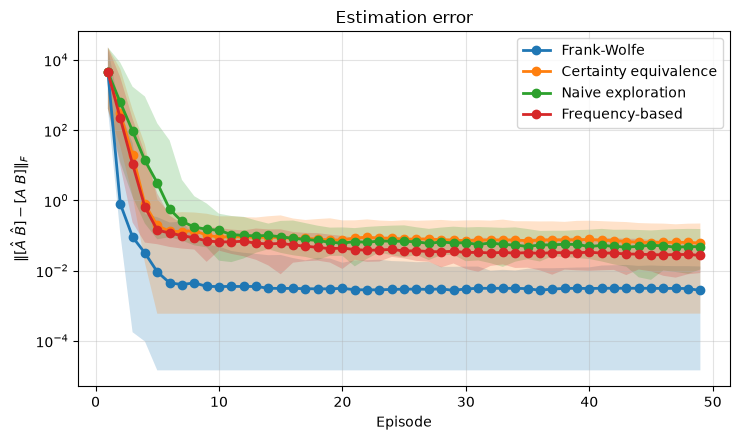

Saved TikZ figure to tikz_figures/system_id_cost_mc.tex


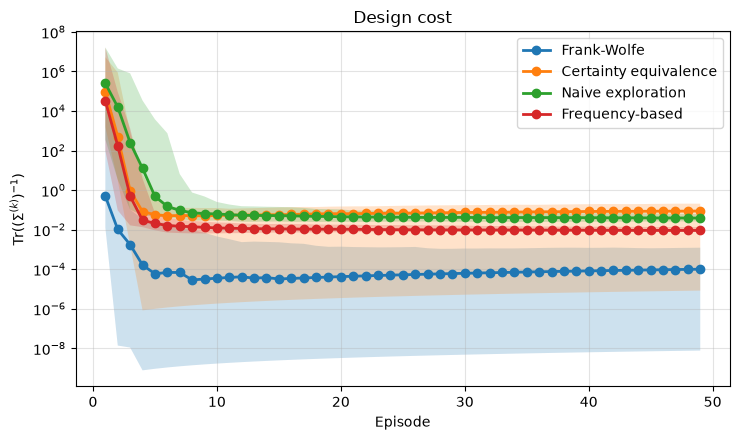

In [51]:
# This block sets up one example system, runs Monte Carlo trials over different
# seeds, compares all four approaches, and saves the two figures as TikZ files.

# -----------------------------
# System and experiment settings
# -----------------------------
A_true = np.array([[0.9, 1.0], [0.0, 0.9]])
B_true = np.array([[0.0], [1.0]])
dx, du = B_true.shape

Sigma_w = 2*np.eye(dx)

T = 15                # rollout horizon
T_for_prior = 15      # initial prior-data horizon
num_episodes = 50     # adaptive episodes
M = 100               # TUNE B2: FW inner iterations
gamma = 1000          # covariance budget

# Monte Carlo seeds. Increase num_mc for smoother percentile bands.
num_mc = 30
mc_seeds = list(range(1, 1 + num_mc))

# Wider percentile band for the shaded region.
lower_q = 0
upper_q = 100

# Stabilizing gain used only for generating the initial prior data.
stabilize_gain = np.zeros((du, dx))

# -----------------------------
# Run Monte Carlo comparison
# -----------------------------
mc_results = run_monte_carlo_experiment(
    A_true=A_true,
    B_true=B_true,
    T=T,
    T_for_prior=T_for_prior,
    num_episodes=num_episodes,
    Sigma_w=Sigma_w,
    M=M,
    gamma=gamma,
    seeds=mc_seeds,
    stabilize_gain=stabilize_gain,
    verbose=True,
)


# -----------------------------
# Plot and export figures
# -----------------------------
# Wider percentile band for the shaded region.
lower_q = 0
upper_q = 100

episodes = np.arange(1, num_episodes)

plot_monte_carlo_bands(
    episodes,
    mc_results,
    quantity='errors',
    ylabel=r'$\|[\hat A\ \hat B]-[A\ B]\|_F$',
    title=f'Estimation error',
    lower_q=lower_q,
    upper_q=upper_q,
    log_scale=True,
    tikz_path='tikz_figures/system_id_error_mc.tex',
)

plot_monte_carlo_bands(
    episodes,
    mc_results,
    quantity='costs',
    ylabel=r'$\operatorname{Tr}((\Sigma^{(k)})^{-1})$',
    title=f'Design cost',
    lower_q=lower_q,
    upper_q=upper_q,
    log_scale=True,
    tikz_path='tikz_figures/system_id_cost_mc.tex',
)